In [1]:
#!pip install gym

In [2]:
from gym.envs.registration import register
import gym
import time
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt

In [3]:
'''
try:
    register(
                id='my_first_env',
                entry_point='gym.envs.toy_text:FrozenLakeEnv',
                kwargs={'map_name': '4x4', 'is_slippery': False},
                max_episode_steps=100,
                reward_threshold=0.78,
            )
except:
         print("Already Registered")
'''

'\ntry:\n    register(\n                id=\'my_first_env\',\n                entry_point=\'gym.envs.toy_text:FrozenLakeEnv\',\n                kwargs={\'map_name\': \'4x4\', \'is_slippery\': False},\n                max_episode_steps=100,\n                reward_threshold=0.78,\n            )\nexcept:\n         print("Already Registered")\n'

In [4]:
'''
env = gym.make('my_first_env')
env.reset()

for step in range(15):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    time.sleep(0.3)
    clear_output(wait=True)

    terminated = False
    truncated = False

    while not (terminated or truncated): # -------------> if done:
        env.reset()
env.close()
'''

"\nenv = gym.make('my_first_env')\nenv.reset()\n\nfor step in range(15):\n    action = env.action_space.sample()\n    observation, reward, terminated, truncated, info = env.step(action)\n    time.sleep(0.3)\n    clear_output(wait=True)\n\n    terminated = False\n    truncated = False\n\n    while not (terminated or truncated): # -------------> if done:\n        env.reset()\nenv.close()\n"

In [5]:

env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
observation, info = env.reset()

terminated = False
truncated = False

while not (terminated or truncated):
    env.render()
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    time.sleep(0.3)
    clear_output(wait=True)

env.close()

C:\ProgramData\anaconda3\Lib\site-packages\gym\envs\toy_text\frozen_lake.py:271: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym("FrozenLake-v1", render_mode="rgb_array")
  logger.warn(
C:\ProgramData\anaconda3\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


In [6]:
observation

7

In [7]:
Gamma = 0.97
alpha = 0.8
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.001
epochs = 20000


action_n = env.action_space.n
state_n = env.observation_space.n
q_table = np.zeros([state_n, action_n])

# Update the table

#### 1: Epsilon Greedy Action Selection

In [8]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    random_num = np.random.random()

    if random_num > epsilon:
        state_index = discrete_state[0] if isinstance(discrete_state, tuple) else discrete_state
        state_row = q_table[state_index, :]
        action = np.argmax(state_row)
    else:
        action = env.action_space.sample()

    return action

#### 2: Compute Next_Q Value

In [9]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    return old_q_value + alpha * (reward + Gamma * next_optimal_q_value - old_q_value)

#### 3: Now We Are Going To Reduice The Epsilon Using Decay_Rate

In [10]:
def reduice_epsilon_value(epsilon, epochs):
    return min_epsilon + (max_epsilon - min_epsilon ) * np.exp(-decay_rate * epochs)

# Agent Training

In [11]:
rewards = []
log_interval = 1000

for episode in range(epochs):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy_action_selection(epsilon, q_table, state)
        new_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        # As state is tuple so int cannot convert tuple to int so we use the following method
        if isinstance(state, tuple):
            state = int(state[0])
        else:
            state = int(state)

        
        old_q_value = q_table[state, action]
        next_optimal_q_value = np.max(q_table[new_state, :])
        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)

        q_table[state, action] = next_q

        total_reward = total_reward + reward

        state = new_state

    episode += 1
    epsilon = reduice_epsilon_value(epsilon, episode)
    rewards.append(total_reward)
    
    if episode % log_interval == 0:
        print(np.sum(rewards))
        
env.close()

257.0
987.0
1903.0
2845.0
3821.0
4803.0
5794.0
6782.0
7779.0
8769.0
9762.0
10756.0
11746.0
12734.0
13723.0
14717.0
15711.0
16706.0
17697.0
18684.0


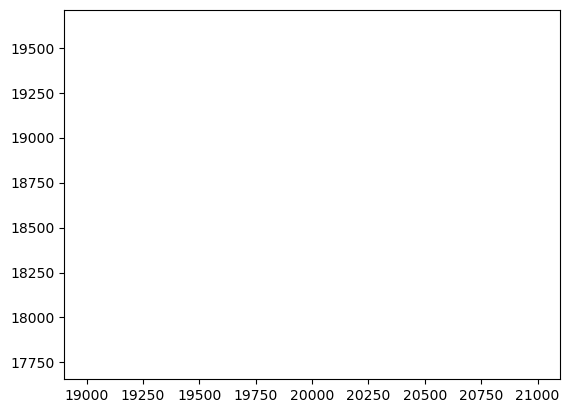

In [12]:
state = env.reset()
state_int = state[0] if isinstance(state, tuple) else state

fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()
fig.canvas.draw()
epoch_plot_tracker = []
total_reward_plot_tracker = []
for step in range(100):
    env.render()
    action = np.argmax(q_table[state_int, :])
    state, reward, terminated, truncated, info = env.step(action)
    
    time.sleep(0.3)
    clear_output(wait = True)
    state_int = state
    
    done = terminated or truncated
    total_reward_plot_tracker.append(np.sum(rewards))
    epoch_plot_tracker.append(episode)
    if episode%log_interval == 0: 
        ax.clear()
        ax.plot(epoch_plot_tracker, total_reward_plot_tracker)
        
        fig.canvas.draw()
        

env.close()